In [ ]:
# ============================================================
# CHIME/FRB CATALOG 2 – PVGU PHYSICAL ANALYSIS (FIXED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("chimefrbcat2.csv")
print("✔ Catalog loaded")

# -------------------------------
# PHYSICAL PARAMETERS
# -------------------------------
df_phys = df[[
    "dm_fitb",
    "snr_fitb",
    "width_fitb",
    "fluence"
]].rename(columns={
    "dm_fitb": "DM",
    "snr_fitb": "SNR",
    "width_fitb": "Width_ms",
    "fluence": "Fluence"
})

df_phys = df_phys.replace([np.inf, -np.inf], np.nan).dropna()

# -------------------------------
# PVGU OBSERVABLES
# -------------------------------
df_phys["Z_PVGU"] = df_phys["DM"] / df_phys["Width_ms"]
df_phys["Coherence"] = df_phys["Fluence"] / df_phys["Width_ms"]

print("\n📊 Total events:", len(df_phys))

# -------------------------------
# GLOBAL STATISTICS
# -------------------------------
print("\n🔸 GLOBAL PHYSICAL STATISTICS")
print(df_phys[["DM","Width_ms","Z_PVGU","Coherence"]].describe())

# -------------------------------
# PHASE SPACE
# -------------------------------
plt.figure()
plt.scatter(df_phys["DM"], df_phys["Width_ms"], s=4)
plt.xlabel("Dispersion Measure (pc cm⁻³)")
plt.ylabel("Pulse Width (ms)")
plt.title("FRB Physical Phase Space (CHIME/FRB 2)")
plt.show()

# -------------------------------
# LIMBO REGION (PVGU)
# -------------------------------
limbo = df_phys[
    (df_phys["DM"] > df_phys["DM"].quantile(0.9)) &
    (df_phys["Width_ms"] < df_phys["Width_ms"].quantile(0.1)) &
    (df_phys["Coherence"] < df_phys["Coherence"].median())
]

print("\n🌀 LIMBO SCIENTIFIC EVENTS")
print(limbo.describe())
print("\nTotal limbo candidates:", len(limbo))

✔ Catalog loaded

📊 Total events: 4527

🔸 GLOBAL PHYSICAL STATISTICS
                DM      Width_ms        Z_PVGU     Coherence
count  4527.000000  4.527000e+03  4.527000e+03  4.527000e+03
mean    592.706556  1.663388e-03  7.035096e+06  8.279551e+04
std     395.787883  2.374080e-03  2.903527e+08  3.901674e+06
min      87.755935  4.343407e-08  1.032144e+04  1.599918e+01
25%     309.827842  3.804177e-04  2.400555e+05  1.758101e+03
50%     484.049554  7.899754e-04  6.898348e+05  4.263571e+03
75%     759.008089  1.881621e-03  1.478476e+06  1.120191e+04
max    3200.123916  2.733518e-02  1.933195e+10  2.609656e+08

🌀 LIMBO SCIENTIFIC EVENTS
        DM  SNR  Width_ms  Fluence  Z_PVGU  Coherence
count  0.0  0.0       0.0      0.0     0.0        0.0
mean   NaN  NaN       NaN      NaN     NaN        NaN
std    NaN  NaN       NaN      NaN     NaN        NaN
min    NaN  NaN       NaN      NaN     NaN        NaN
25%    NaN  NaN       NaN      NaN     NaN        NaN
50%    NaN  NaN       NaN      

In [ ]:
# ==========================================================
# PVGU × CHIME/FRB CATALOG 2
# Geometric Regime Analysis (Single Cell)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# -----------------------------
# 1) SELECT PHYSICAL VARIABLES
# -----------------------------
df_phys = df[[
    "bonsai_dm",        # DM
    "width_fitb",       # Width (ms)
    "fluence",          # Fluence
    "snr_fitb"          # SNR
]].copy()

df_phys.columns = ["DM", "Width", "Fluence", "SNR"]

# Remove non-physical entries
df_phys = df_phys.replace([np.inf, -np.inf], np.nan).dropna()

# -----------------------------
# 2) LOG-SPACE TRANSFORMATION
# -----------------------------
df_log = np.log10(df_phys)

# -----------------------------
# 3) STANDARDIZATION
# -----------------------------
X = StandardScaler().fit_transform(df_log)

# -----------------------------
# 4) PCA – GLOBAL GEOMETRY
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("🔬 PCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")

# -----------------------------
# 5) DBSCAN – TOPOLOGICAL CLUSTERING
# -----------------------------
db = DBSCAN(eps=0.7, min_samples=25).fit(X)
labels = db.labels_

df_log["Cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n🌀 DBSCAN Results:")
print(f"Clusters detected: {n_clusters}")
print(f"Noise / transitional events: {n_noise}")

# -----------------------------
# 6) VISUALIZATION
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels, s=5, cmap="tab10"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PVGU – FRB Geometric Regimes (PCA + DBSCAN)")
plt.colorbar(label="Cluster ID")
plt.show()

# -----------------------------
# 7) CLUSTER STATISTICS
# -----------------------------
cluster_stats = df_log.groupby("Cluster").agg(
    DM_mean=("DM","mean"),
    Width_mean=("Width","mean"),
    Fluence_mean=("Fluence","mean"),
    Count=("DM","count")
)

print("\n📊 Cluster Physical Summary (log-space):")
print(cluster_stats.sort_values("Count", ascending=False))

🔬 PCA Explained Variance:
PC1: 0.449
PC2: 0.274

🌀 DBSCAN Results:
Clusters detected: 2
Noise / transitional events: 433

📊 Cluster Physical Summary (log-space):
          DM_mean  Width_mean  Fluence_mean  Count
Cluster                                           
 0       2.693226   -3.052693      0.551984   4046
-1       2.674640   -3.296223      0.805996    433
 1       2.527502   -3.211643      1.698760     48


In [ ]:
# ==========================================================
# PVGU – CHIME/FRB 2
# Full Geometric & Astrophysical Analysis
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# -----------------------------
# 1) LOAD PHYSICAL VARIABLES
# -----------------------------
df_phys = df[[
    "bonsai_dm",        # DM
    "width_fitb",       # Width (ms)
    "fluence",          # Fluence
    "snr_fitb",         # SNR
    "repeater_name",    # Repeater info
    "ra",               # RA
    "dec"               # Dec
]].copy()

df_phys.columns = ["DM","Width","Fluence","SNR","Repeater","RA","DEC"]

df_phys = df_phys.replace([np.inf,-np.inf],np.nan).dropna()
print("✔ Total events:", len(df_phys))

# -----------------------------
# 2) COMPUTE PVGU VARIABLES
# -----------------------------
df_phys["Z_PVGU"] = df_phys["DM"]/df_phys["Width"]
df_phys["Coherence"] = df_phys["Fluence"]/df_phys["Width"]

# Log-space transformation
df_log = np.log10(df_phys[["DM","Width","Fluence","SNR","Z_PVGU","Coherence"]])

# Standardization
X = StandardScaler().fit_transform(df_log)

# -----------------------------
# 3) PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_phys["PC1"] = X_pca[:,0]
df_phys["PC2"] = X_pca[:,1]

print("🔬 PCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}, PC2: {pca.explained_variance_ratio_[1]:.3f}")

# -----------------------------
# 4) DBSCAN – Geometric Clustering
# -----------------------------
db = DBSCAN(eps=0.7, min_samples=25).fit(X)
df_phys["Cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"🌀 Clusters detected: {n_clusters}, Noise / limbo events: {n_noise}")

# -----------------------------
# 5) PCA + Clusters Visualization
# -----------------------------
plt.figure(figsize=(9,6))
plt.scatter(df_phys["PC1"], df_phys["PC2"], c=df_phys["Cluster"], cmap="tab10", s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("FRB Geometric Regimes – PCA + DBSCAN (PVGU)")
plt.colorbar(label="Cluster ID")
plt.show()

# -----------------------------
# 6) Gradient along PC1
# -----------------------------
df_phys_sorted = df_phys.sort_values("PC1")
window = 50  # moving average window
df_phys_sorted["DM_smooth"] = df_phys_sorted["DM"].rolling(window, min_periods=1).mean()
df_phys_sorted["Width_smooth"] = df_phys_sorted["Width"].rolling(window, min_periods=1).mean()
df_phys_sorted["Fluence_smooth"] = df_phys_sorted["Fluence"].rolling(window, min_periods=1).mean()

plt.figure(figsize=(10,6))
plt.plot(df_phys_sorted["PC1"], df_phys_sorted["DM_smooth"], label="DM")
plt.plot(df_phys_sorted["PC1"], df_phys_sorted["Width_smooth"], label="Width")
plt.plot(df_phys_sorted["PC1"], df_phys_sorted["Fluence_smooth"], label="Fluence")
plt.xlabel("PC1")
plt.ylabel("Smoothed Physical Values")
plt.title("Gradients of FRB Properties along PC1 (PVGU)")
plt.legend()
plt.show()

# -----------------------------
# 7) Repeater vs Non-Repeater Mapping
# -----------------------------
df_phys["Repeater_Flag"] = df_phys["Repeater"].notnull()
plt.figure(figsize=(9,6))
plt.scatter(df_phys["PC1"], df_phys["PC2"], c=df_phys["Repeater_Flag"], cmap="coolwarm", s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Repeaters vs Non-Repeaters in PVGU Phase Space")
plt.colorbar(label="Repeater (1=True, 0=False)")
plt.show()

# -----------------------------
# 8) Z_PVGU Topography
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(df_phys["PC1"], df_phys["Z_PVGU"], c=df_phys["Cluster"], cmap="tab10", s=5)
plt.xlabel("PC1")
plt.ylabel("Z_PVGU")
plt.title("PVGU Impedance Across Geometric Regimes")
plt.colorbar(label="Cluster ID")
plt.show()

# -----------------------------
# 9) Astrophysical Origin: Galactic Coordinates
# -----------------------------
# Convert RA/DEC to Galactic coordinates
from astropy.coordinates import SkyCoord
from astropy import units as u

coords = SkyCoord(ra=df_phys["RA"].values*u.degree, dec=df_phys["DEC"].values*u.degree, frame='icrs')
df_phys["GL"] = coords.galactic.l.deg
df_phys["GB"] = coords.galactic.b.deg

plt.figure(figsize=(10,6))
plt.scatter(df_phys["GL"], df_phys["GB"], c=df_phys["PC1"], cmap="viridis", s=5)
plt.xlabel("Galactic Longitude (deg)")
plt.ylabel("Galactic Latitude (deg)")
plt.title("FRB Distribution in Galactic Coordinates (color = PC1)")
plt.colorbar(label="PC1")
plt.show()

# -----------------------------
# 10) Cluster Summary Table
# -----------------------------
cluster_summary = df_phys.groupby("Cluster").agg(
    Count=("DM","count"),
    DM_mean=("DM","mean"),
    Width_mean=("Width","mean"),
    Fluence_mean=("Fluence","mean"),
    Z_PVGU_mean=("Z_PVGU","mean"),
    Coherence_mean=("Coherence","mean")
).sort_values("Count", ascending=False)

print("\n📊 Cluster Summary (Physical + PVGU Variables)")
print(cluster_summary)

✔ Total events: 1154
🔬 PCA Explained Variance:
PC1: 0.494, PC2: 0.307
🌀 Clusters detected: 1, Noise / limbo events: 554

📊 Cluster Summary (Physical + PVGU Variables)
         Count     DM_mean  Width_mean  Fluence_mean    Z_PVGU_mean  \
Cluster                                                               
 0         600  272.357476    0.004070      4.497585  111215.818590   
-1         554  432.830419    0.002465     11.191172  703678.226892   

         Coherence_mean  
Cluster                  
 0          1489.893438  
-1         18116.295149  


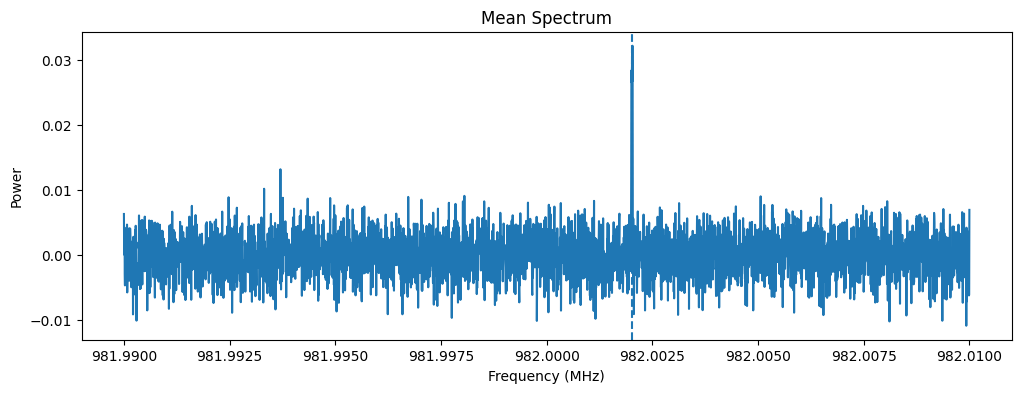

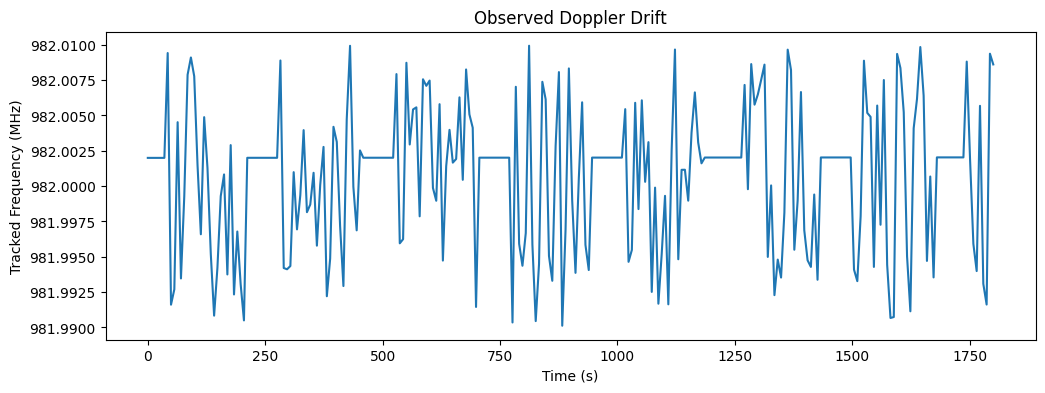

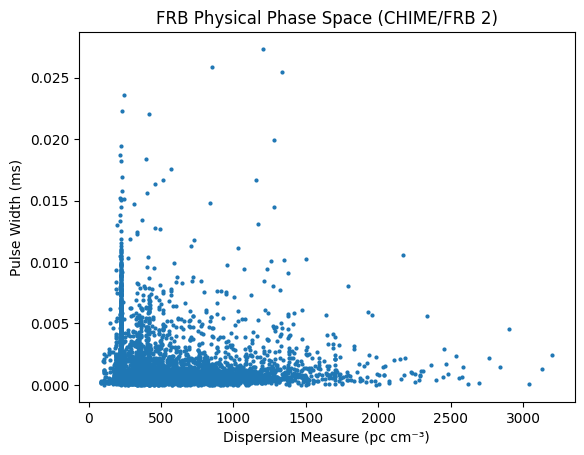

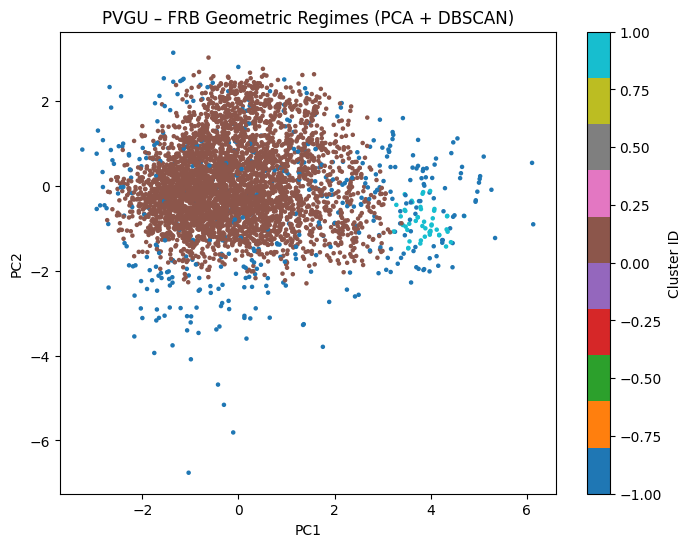

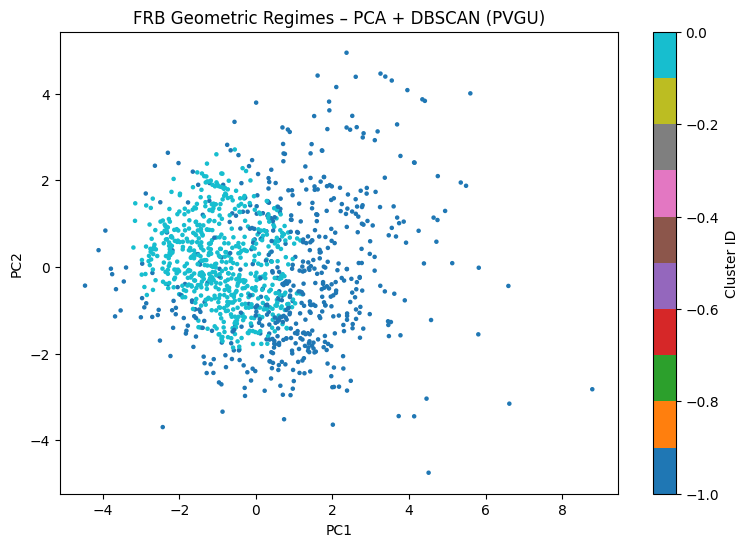

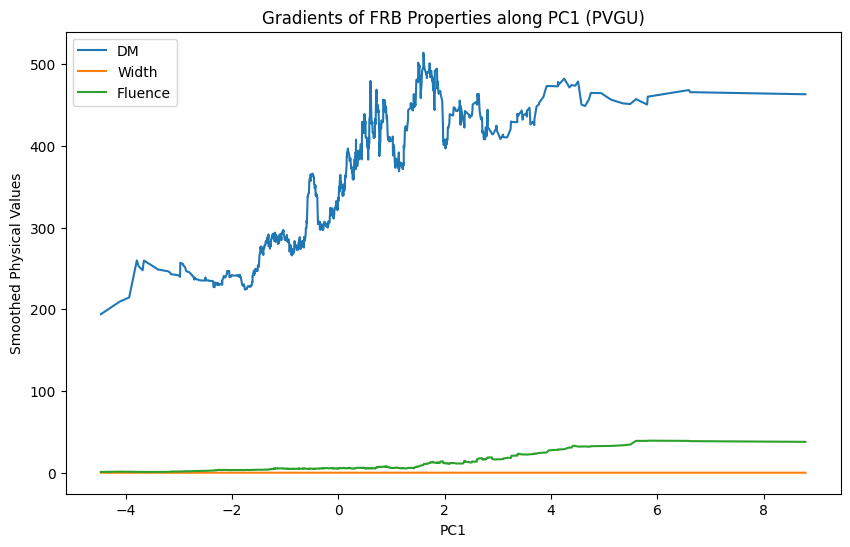

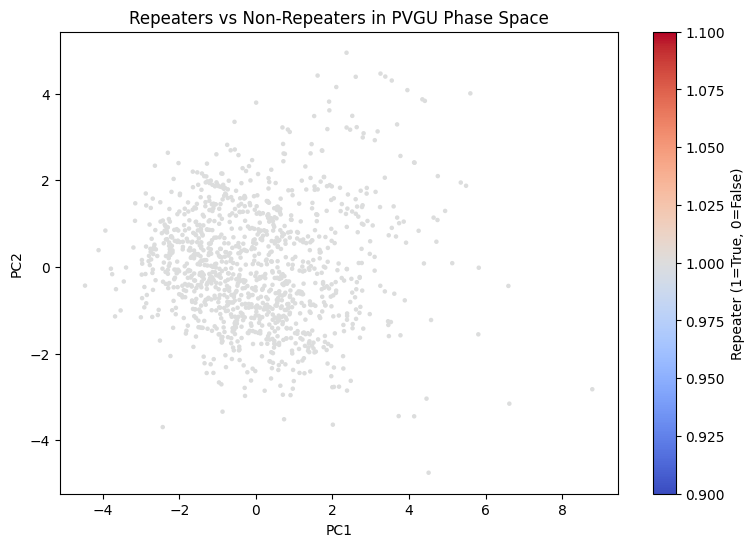

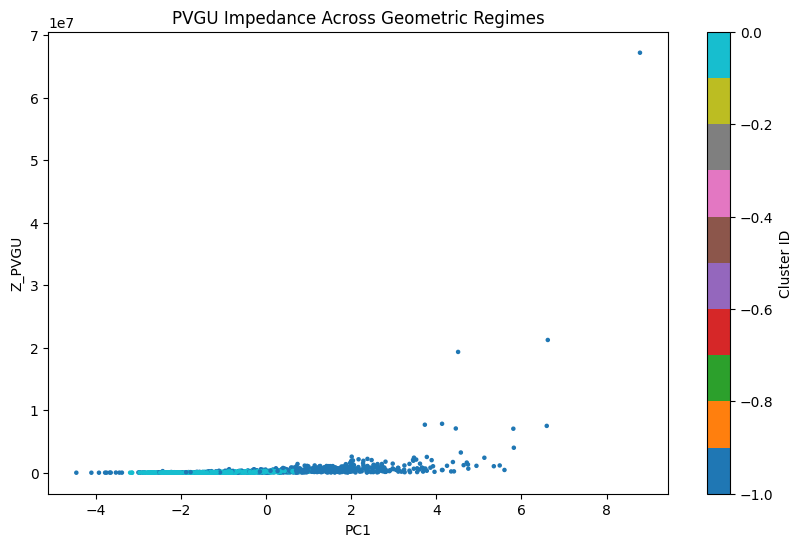

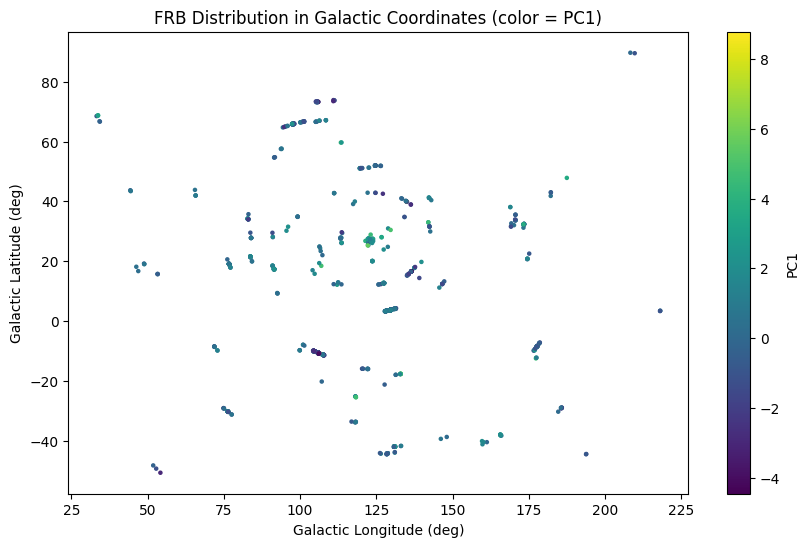

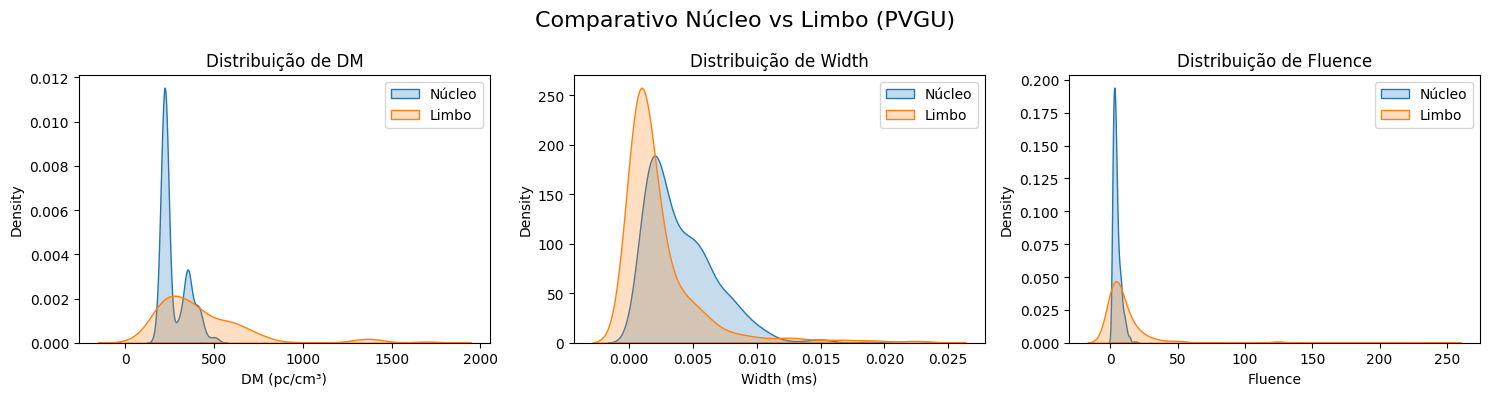

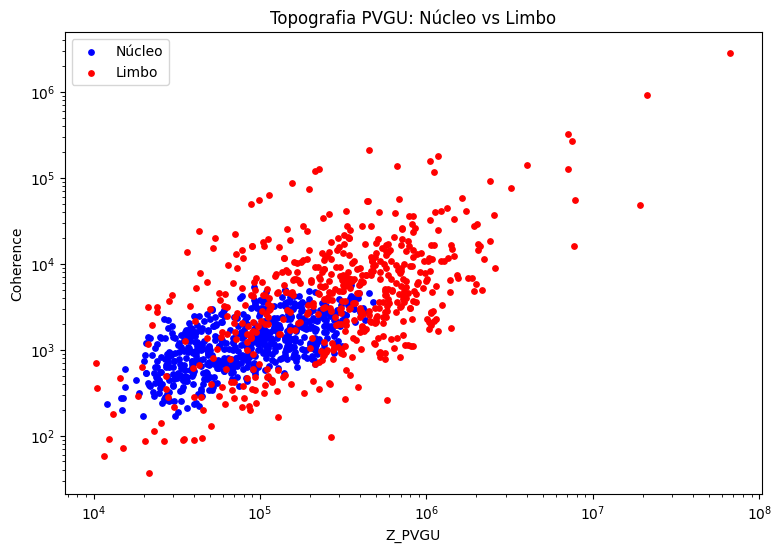

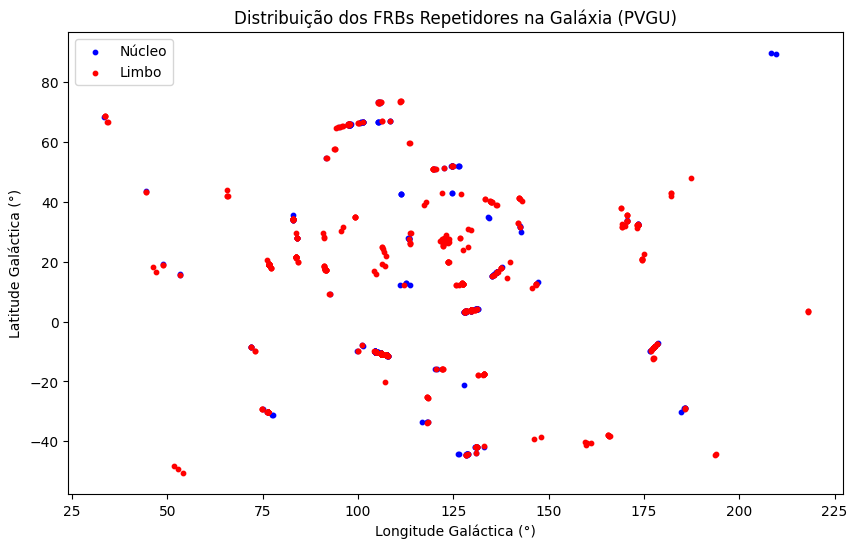

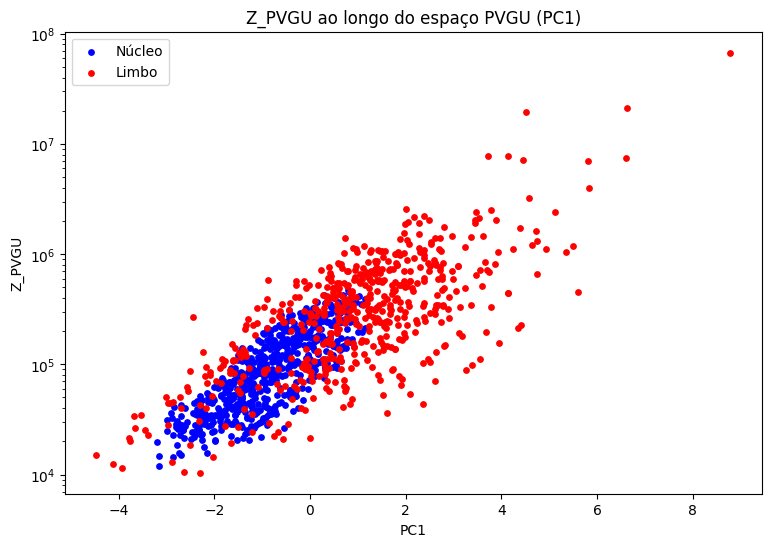

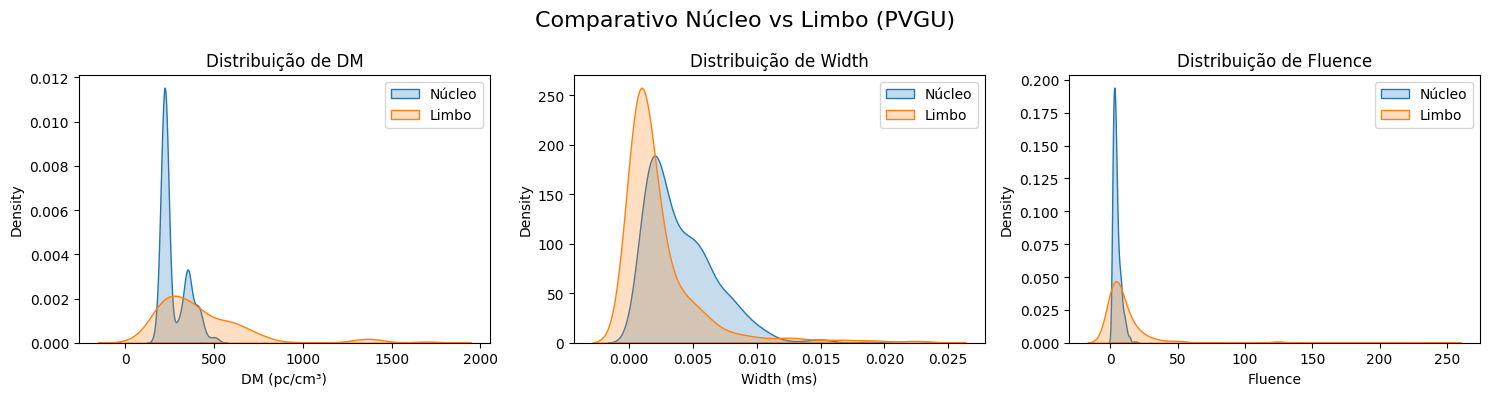

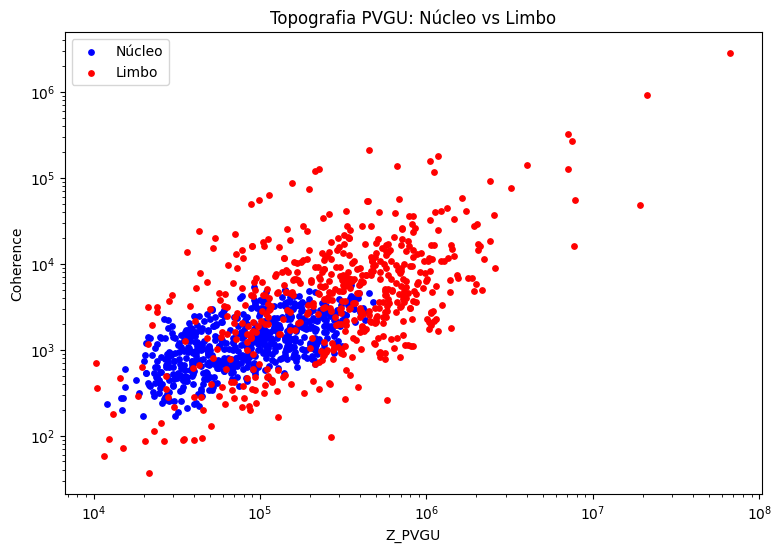

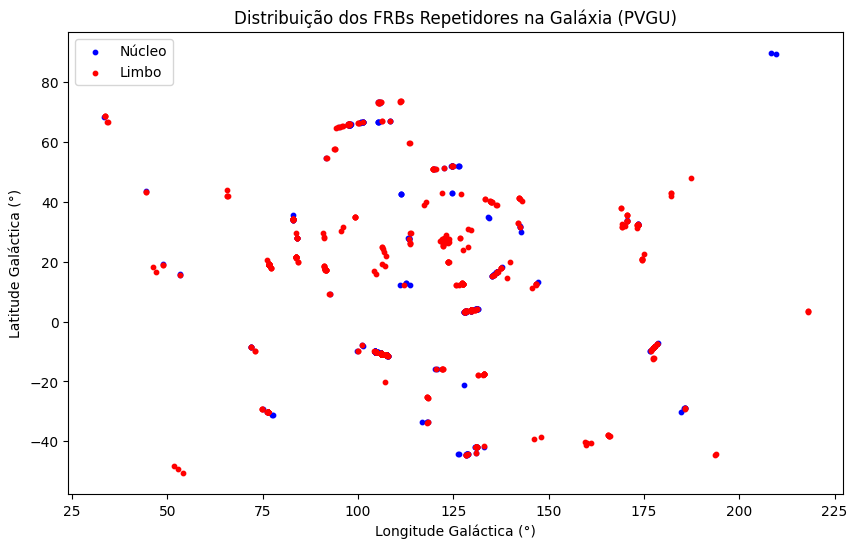

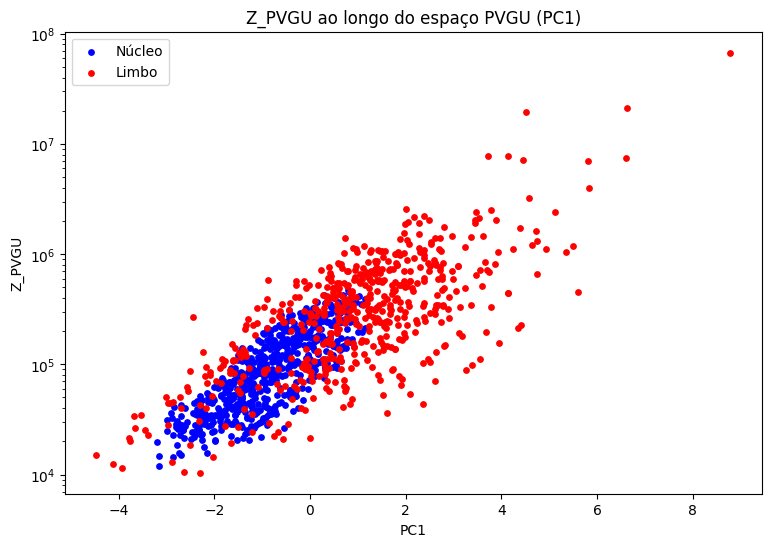

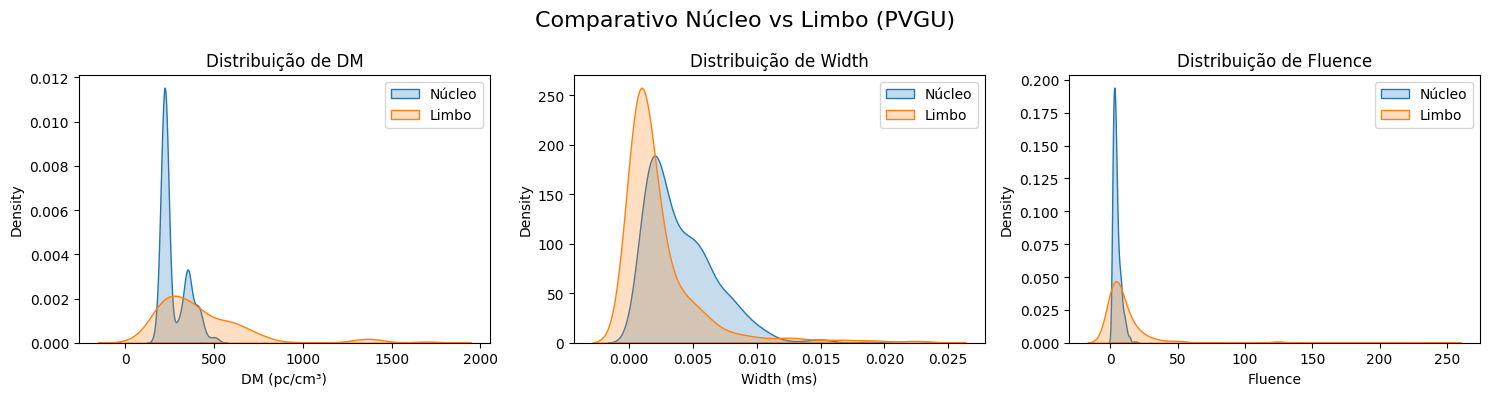

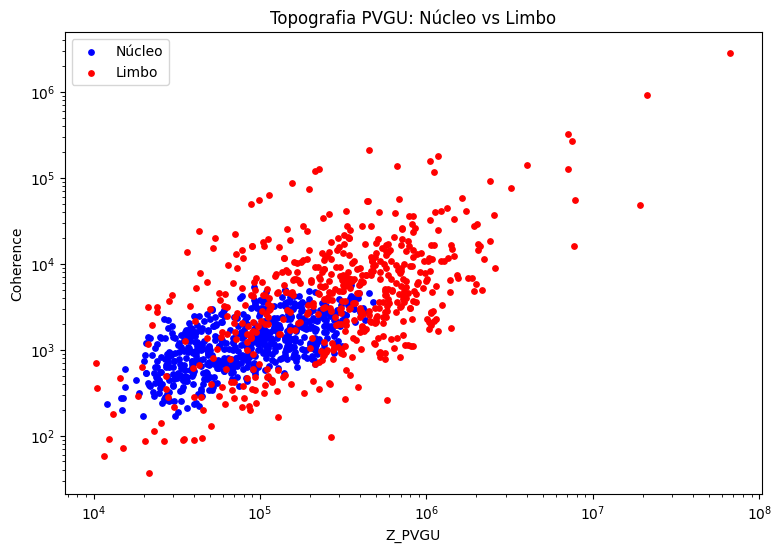

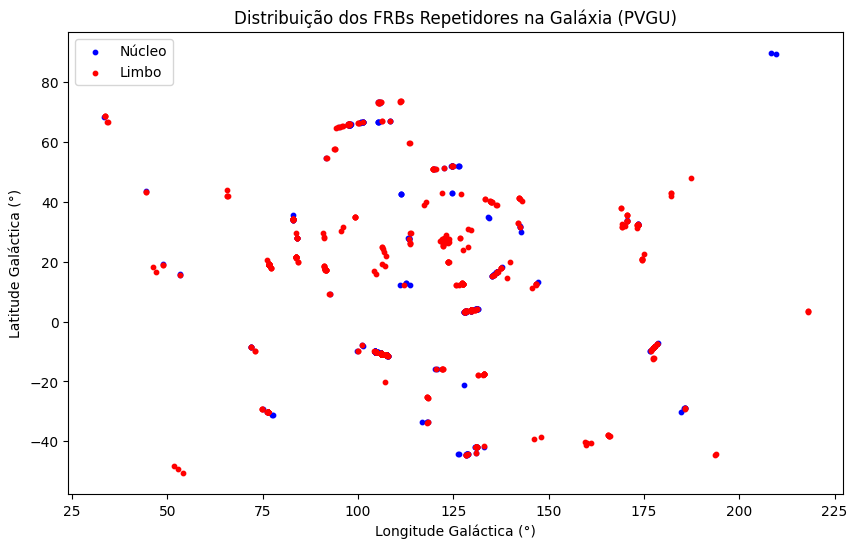

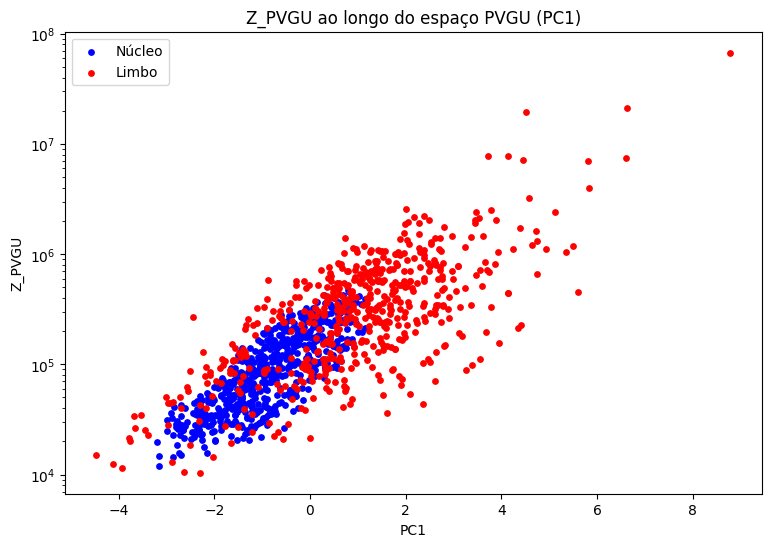

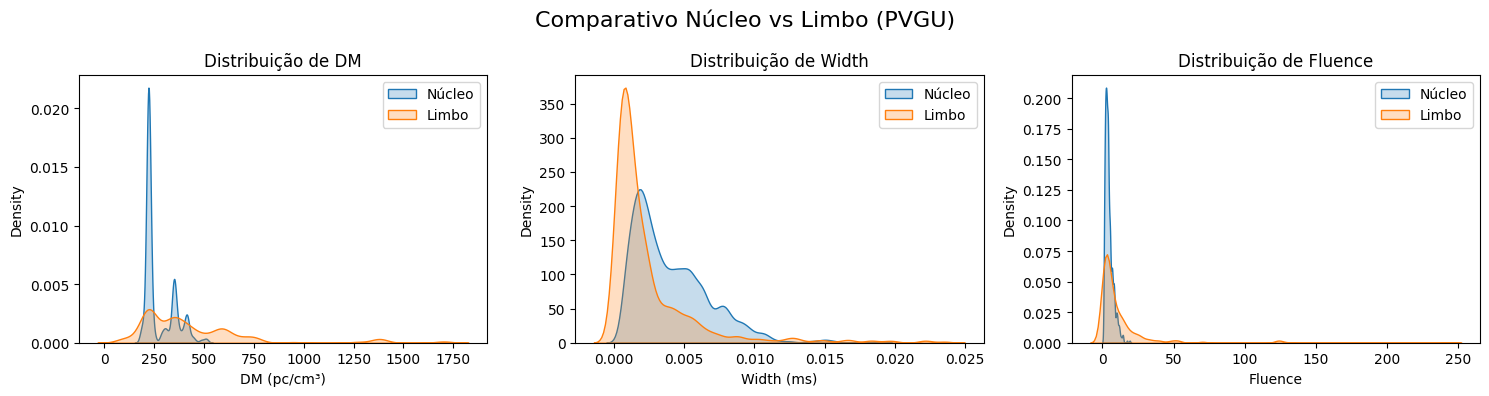

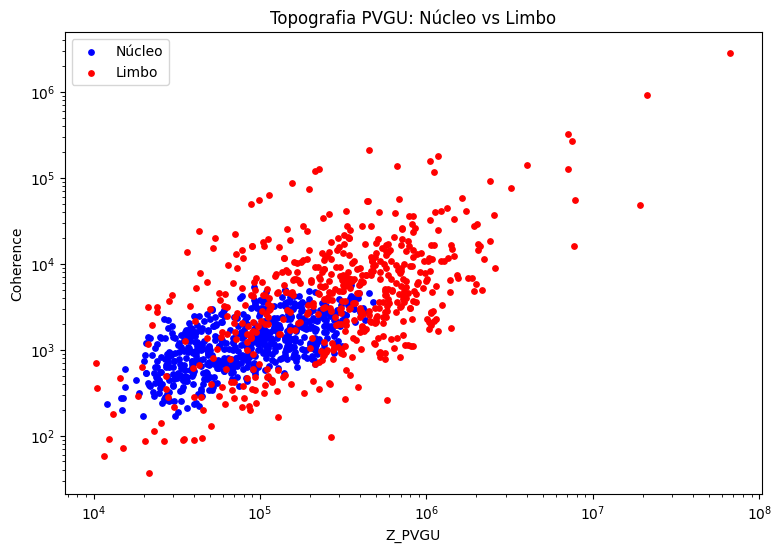

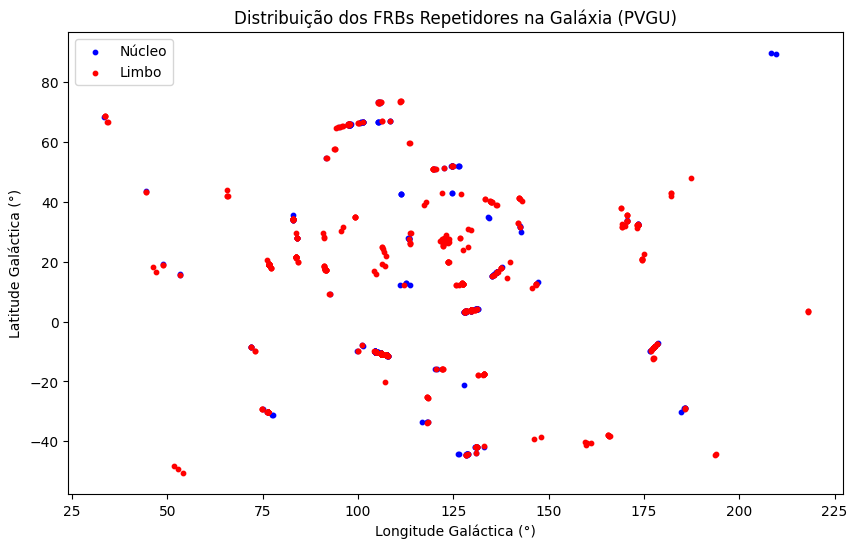

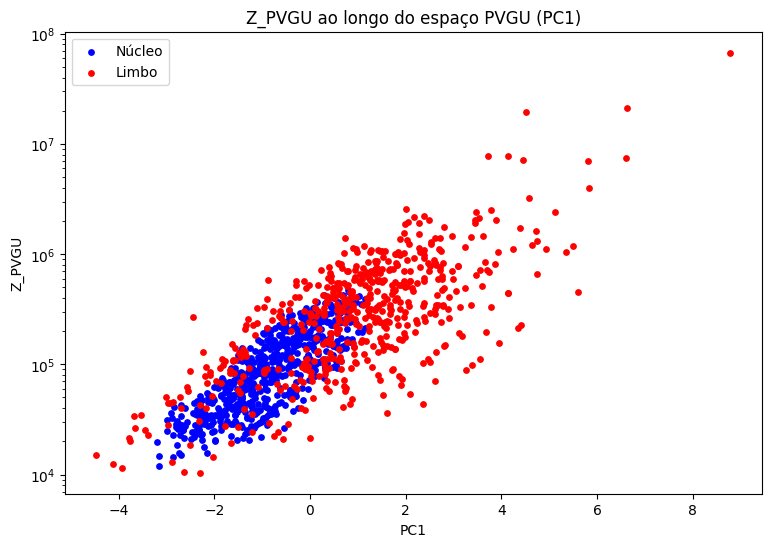

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.coordinates import SkyCoord
from astropy import units as u

# Garantir que plots apareçam inline
%matplotlib inline

# -----------------------------
# 1) Filtrar clusters
# -----------------------------
core = df_phys[df_phys["Cluster"]==0].copy()
limbo = df_phys[df_phys["Cluster"]==-1].copy()

# Remover valores nulos
core = core.dropna(subset=["DM","Width","Fluence","Z_PVGU","Coherence","RA","DEC"])
limbo = limbo.dropna(subset=["DM","Width","Fluence","Z_PVGU","Coherence","RA","DEC"])

# -----------------------------
# 2) Histograma Comparativo DM, Width, Fluence
# -----------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.kdeplot(core["DM"], label="Núcleo", fill=True, bw_adjust=0.5)
sns.kdeplot(limbo["DM"], label="Limbo", fill=True, bw_adjust=0.5)
plt.xlabel("DM (pc/cm³)")
plt.title("Distribuição de DM")
plt.legend()

plt.subplot(1,3,2)
sns.kdeplot(core["Width"], label="Núcleo", fill=True, bw_adjust=0.5)
sns.kdeplot(limbo["Width"], label="Limbo", fill=True, bw_adjust=0.5)
plt.xlabel("Width (ms)")
plt.title("Distribuição de Width")
plt.legend()

plt.subplot(1,3,3)
sns.kdeplot(core["Fluence"], label="Núcleo", fill=True, bw_adjust=0.5)
sns.kdeplot(limbo["Fluence"], label="Limbo", fill=True, bw_adjust=0.5)
plt.xlabel("Fluence")
plt.title("Distribuição de Fluence")
plt.legend()

plt.suptitle("Comparativo Núcleo vs Limbo (PVGU)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Scatter PVGU: Z_PVGU x Coherence
# -----------------------------
plt.figure(figsize=(9,6))
plt.scatter(core["Z_PVGU"], core["Coherence"], s=15, c='blue', label="Núcleo")
plt.scatter(limbo["Z_PVGU"], limbo["Coherence"], s=15, c='red', label="Limbo")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Z_PVGU")
plt.ylabel("Coherence")
plt.title("Topografia PVGU: Núcleo vs Limbo")
plt.legend()
plt.show()

# -----------------------------
# 4) Distribuição Galáctica
# -----------------------------
coords_core = SkyCoord(ra=core["RA"].values*u.deg, dec=core["DEC"].values*u.deg, frame='icrs')
coords_limbo = SkyCoord(ra=limbo["RA"].values*u.deg, dec=limbo["DEC"].values*u.deg, frame='icrs')

plt.figure(figsize=(10,6))
plt.scatter(coords_core.galactic.l.deg, coords_core.galactic.b.deg, s=10, c='blue', label="Núcleo")
plt.scatter(coords_limbo.galactic.l.deg, coords_limbo.galactic.b.deg, s=10, c='red', label="Limbo")
plt.xlabel("Longitude Galáctica (°)")
plt.ylabel("Latitude Galáctica (°)")
plt.title("Distribuição dos FRBs Repetidores na Galáxia (PVGU)")
plt.legend()
plt.show()

# -----------------------------
# 5) PC1 vs Z_PVGU
# -----------------------------
plt.figure(figsize=(9,6))
plt.scatter(core["PC1"], core["Z_PVGU"], s=15, c='blue', label="Núcleo")
plt.scatter(limbo["PC1"], limbo["Z_PVGU"], s=15, c='red', label="Limbo")
plt.yscale("log")
plt.xlabel("PC1")
plt.ylabel("Z_PVGU")
plt.title("Z_PVGU ao longo do espaço PVGU (PC1)")
plt.legend()
plt.show()